In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
import os, csv

from helpers import load_data, preprocess, normalize, create_window, train_and_evaluate_models, \
    plot_performance, print_model_summaries, write_model_results_to_csv, WindowGenerator, \
    baseline, linear, dense, simple_rnn, cnn, lstm, autoregressive, bi_lstm, load_all_data, create_csv, \
    calculate_original_performance, drop_feature_and_evaluate, create_feature_csv, plot_training_history, compile_and_fit

2024-11-07 18:38:53.765576: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("./Station3_precipitation_chance_hourly.csv", index_col=0, parse_dates=True)
df = df[~df.index.duplicated(keep='first')]
#df = preprocess(df)
#df = normalize(df)
df = df.drop(columns = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50'])
df.head()
n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]
scaler = StandardScaler()
train_df_scaled = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns, index=train_df.index)

# Use the same scaler to transform validation and test data
val_df_scaled = pd.DataFrame(scaler.transform(val_df), columns=val_df.columns, index=val_df.index)
test_df_scaled = pd.DataFrame(scaler.transform(test_df), columns=test_df.columns, index=test_df.index)



In [3]:
window = create_window(
        input_width=24,
        label_width=1,
        shift=1,
        train_df=train_df_scaled,
        val_df=val_df_scaled,
        test_df=test_df_scaled,
        label_columns=['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 'Predicted_Rain_Next_Hour_24h']
    )
df.head()

,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,...,Rain_Chance_Percentage_6d,Rain_Chance_Percentage_7d,Rain_Chance_Percentage,Predict_1days_Percentage,Predict_2days_Percentage,Predict_3days_Percentage,Predict_4days_Percentage,Predict_5days_Percentage,Predict_6days_Percentage,Predict_7days_Percentage
2015-01-03 00:00:00,0.76,0.762,2.018,98.9,0.18,0.516587,-0.613467,-4.722481e-12,1.000000,0.035903,...,1.0,1.0,100.0,90.229309,79.063303,69.255946,65.473767,59.905657,55.965132,50.301413
2015-01-03 01:00:00,0.51,0.508,2.149,98.6,0.22,0.124271,0.619662,2.588190e-01,0.965926,0.036619,...,1.0,1.0,100.0,90.386243,79.275990,69.256085,64.778829,59.724527,54.860725,50.546778
2015-01-03 02:00:00,0.00,0.000,2.011,99.3,0.04,-0.310663,0.225710,5.000000e-01,0.866025,0.037336,...,1.0,1.0,100.0,58.680978,56.487931,52.046260,52.462970,50.613220,49.346779,46.877992
2015-01-03 03:00:00,0.00,0.000,2.131,98.8,0.02,0.337787,-0.651656,7.071068e-01,0.707107,0.038052,...,1.0,1.0,100.0,59.311099,56.574130,51.770722,51.109842,51.084563,50.397545,47.645721
2015-01-03 04:00:00,0.00,0.000,2.342,98.0,0.00,0.816904,-1.473734,8.660254e-01,0.500000,0.038768,...,1.0,1.0,100.0,58.543451,56.083361,50.899806,50.956585,51.002514,49.894245,47.411484


In [4]:
val_performance = {}
performance = {}
num_features = df.shape[1]
lstm_model = lstm(5, num_features)
history = compile_and_fit(lstm_model, window)

val_performance['Lstm'] = lstm_model.evaluate(window.val, return_dict=True)
performance['Lstm'] = lstm_model.evaluate(window.test, verbose=0, return_dict=True)

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 1.2792 - mean_absolute_error: 0.7533 - val_loss: 0.9477 - val_mean_absolute_error: 0.6564
Epoch 2/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.2630 - mean_absolute_error: 0.7359 - val_loss: 0.9457 - val_mean_absolute_error: 0.6525
Epoch 3/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.2596 - mean_absolute_error: 0.7350 - val_loss: 0.9452 - val_mean_absolute_error: 0.6521
Epoch 4/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 1.2598 - mean_absolute_error: 0.7351 - val_loss: 0.9449 - val_mean_absolute_error: 0.6513
Epoch 5/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 1.2611 - mean_absolute_error: 0.7353 - val_loss: 0.9471 - val_mean_absolute_error: 0.6550
Epoch 6/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 1.2607 - mean_absolute_error: 0.7353 - val_loss: 0.9457 - val_mean_absolute_error: 0.6528
Epoch 7/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.2631 - mea

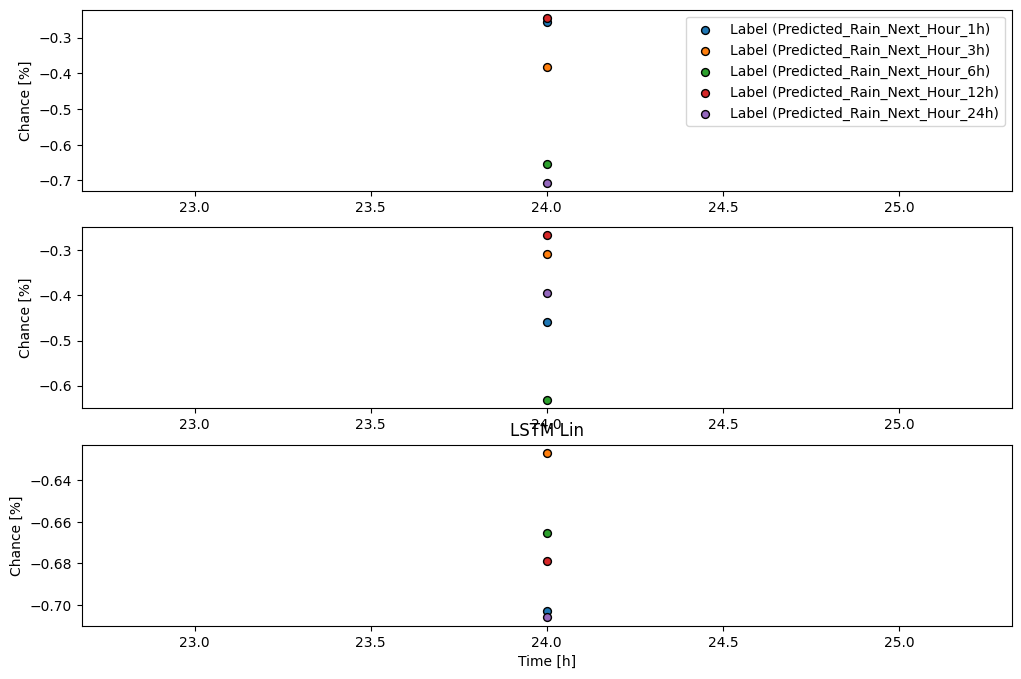

In [5]:
window.plot("LSTM", config="Lin")


In [6]:
import numpy as np

def apply_decay(predictions, intervals=[1, 3, 6, 12, 24], alpha=0.1):
    """
    Applies exponential decay to predictions based on intervals.
    
    Parameters:
        predictions (np.array): The predictions array (num_samples, num_intervals).
        intervals (list): List of interval times.
        alpha (float): Decay rate for exponential adjustment.
    
    Returns:
        np.array: Adjusted predictions with decay applied.
    """
    decay_factors = np.exp(-alpha * np.array(intervals))
    return predictions * decay_factors

In [7]:
# Combine train, validation, and test data for full prediction if necessary
full_data = df.copy()
full_data_scaled = pd.DataFrame(scaler.transform(full_data), columns=train_df.columns, index=full_data.index)
target_columns = ['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 
                  'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 
                  'Predicted_Rain_Next_Hour_24h']

# Create a dictionary to store individual scalers for each target column
target_scalers = {col: StandardScaler().fit(full_data_scaled[[col]]) for col in target_columns}

full_data_scaled = full_data.copy()
for col in target_columns:
    full_data_scaled[col] = target_scalers[col].transform(full_data[[col]])

feature_columns = [col for col in df.columns if col not in target_columns]

# Step 1: Fit scalers for feature and target columns separately
# Scaler for feature columns
feature_scaler = StandardScaler()
feature_scaler.fit(full_data_scaled[feature_columns])
full_data_scaled[feature_columns] = feature_scaler.transform(full_data_scaled[feature_columns])

# Create a window generator for the full dataset
full_window = create_window(
    input_width=24,
    label_width=1,
    shift=1,
    train_df=full_data_scaled,
    val_df=val_df_scaled,  # Use the existing val and test for other purposes
    test_df=test_df_scaled,
    label_columns=['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 'Predicted_Rain_Next_Hour_24h']
)

# Generate predictions
predictions = []
for inputs, _ in full_window.make_dataset(full_data_scaled):
    batch_predictions = lstm_model.predict(inputs)
    adjusted_predictions = apply_decay(batch_predictions)
    predictions.append(adjusted_predictions)

# Flatten and reshape predictions to fit into the DataFrame
predictions = np.concatenate(predictions, axis=0)  # Shape should match the total number of rows in full_data
# Inverse-transform each prediction column separately
predictions_original_scale = np.zeros_like(predictions)  # Array to store inversely scaled predictions
for i, col in enumerate(target_columns):
    # Apply inverse transform on each column
    predictions_original_scale[:, i] = target_scalers[col].inverse_transform(predictions[:, i].reshape(-1, 1)).flatten()

aligned_full_data = full_data.iloc[full_window.input_width:]  # Adjusting for the input window length

# Add predictions as new columns in `aligned_full_data`
for i, interval in enumerate(['Ppt_pred_1hr', 'Ppt_pred_3hr', 'Ppt_pred_6hr', 'Ppt_pred_12hr', 'Ppt_pred_24hr']):
    aligned_full_data[interval] = predictions_original_scale[:, i]

# Display the resulting DataFrame with predictions
aligned_full_data.head()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━

2024-11-07 18:44:01.633432: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/var/folders/rj/tq5xjpk51x314wz5r4xtz4940000gp/T/ipykernel_21704/1789197233.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aligned_full_data[interval] = predictions_original_scale[:, i]
/var/folders/rj/tq5xjpk51x314wz5r4xtz4940000gp/T/ipykernel_21704/1789197233.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aligned_full_data[interval] = predicti

,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,...,Predict_3days_Percentage,Predict_4days_Percentage,Predict_5days_Percentage,Predict_6days_Percentage,Predict_7days_Percentage,Ppt_pred_1hr,Ppt_pred_3hr,Ppt_pred_6hr,Ppt_pred_12hr,Ppt_pred_24hr
2015-01-04 00:00:00,0.0,0.0,4.278,74.50,0.00,0.020215,-0.023502,-4.239421e-13,1.000000,0.053089,...,1.0,1.000000,1.000000,1.000000,1.00000,0.137993,0.353085,0.198403,0.107051,0.010830
2015-01-04 01:00:00,0.0,0.0,3.284,66.57,0.01,0.056133,-0.059775,2.588190e-01,0.965926,0.053804,...,1.0,1.000000,1.000000,1.000000,1.33659,0.092477,0.120723,0.152411,0.050422,-0.004173
2015-01-04 02:00:00,0.0,0.0,7.950,51.04,0.03,0.698664,-0.669995,5.000000e-01,0.866025,0.054520,...,1.0,1.000000,1.000000,1.340632,1.00000,0.048367,0.060579,0.035026,-0.014642,-0.014222
2015-01-04 03:00:00,0.0,0.0,7.920,56.43,0.00,0.820661,-0.336578,7.071068e-01,0.707107,0.055236,...,1.0,1.185796,1.146559,1.120621,1.00000,0.143838,0.252441,0.168767,0.059972,-0.001785
2015-01-04 04:00:00,0.0,0.0,6.674,66.01,0.00,1.421035,-0.199713,8.660254e-01,0.500000,0.055951,...,1.0,1.000000,1.403887,1.000000,1.00000,0.148607,0.103144,0.147907,0.013040,0.004610


In [8]:
aligned_full_data.to_csv('./Station3_model_precipitation_chance_hourly.csv', index=True)

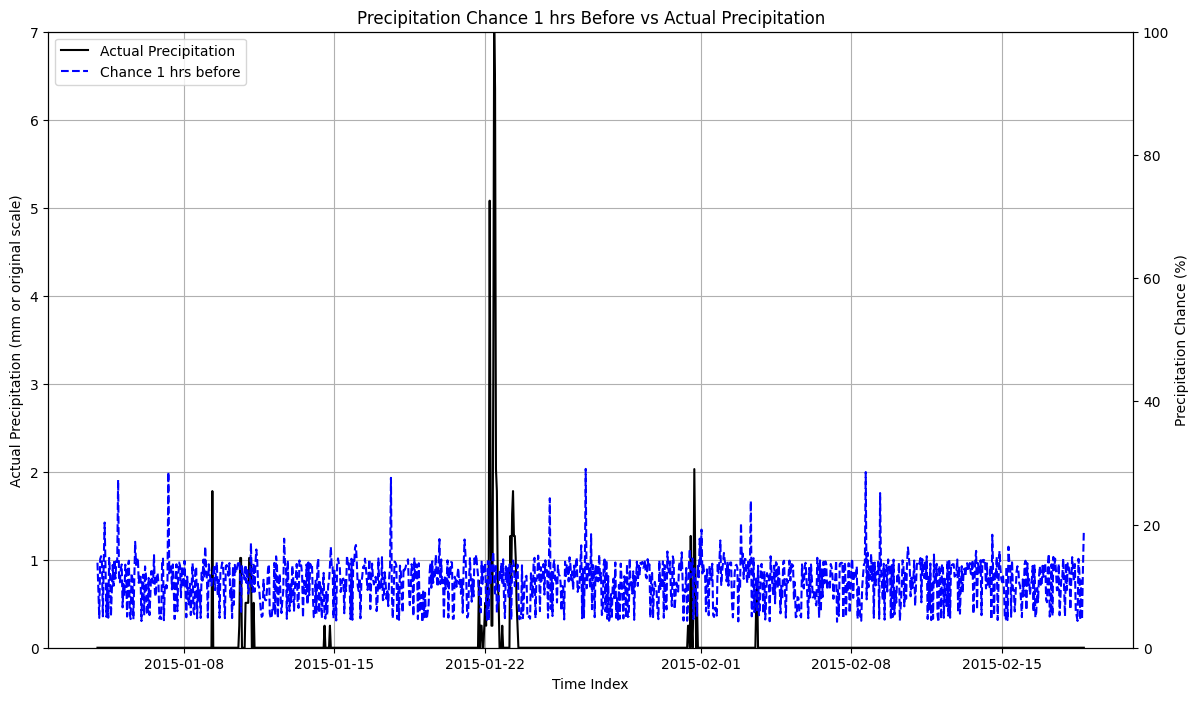

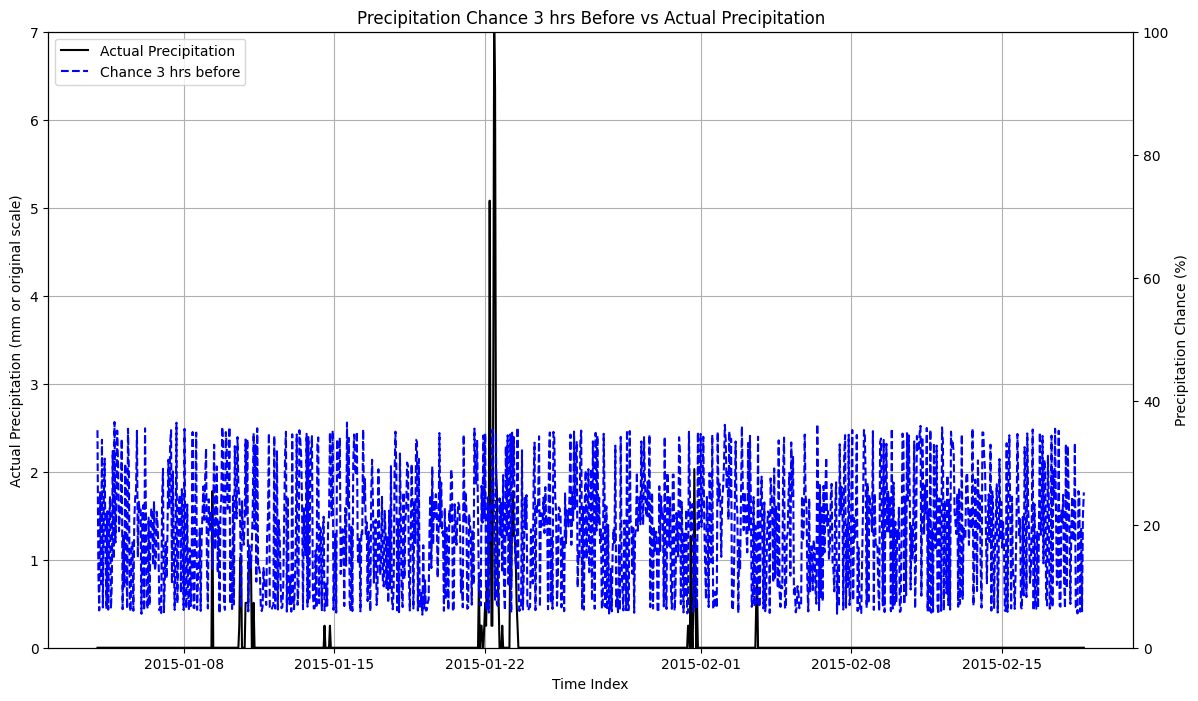

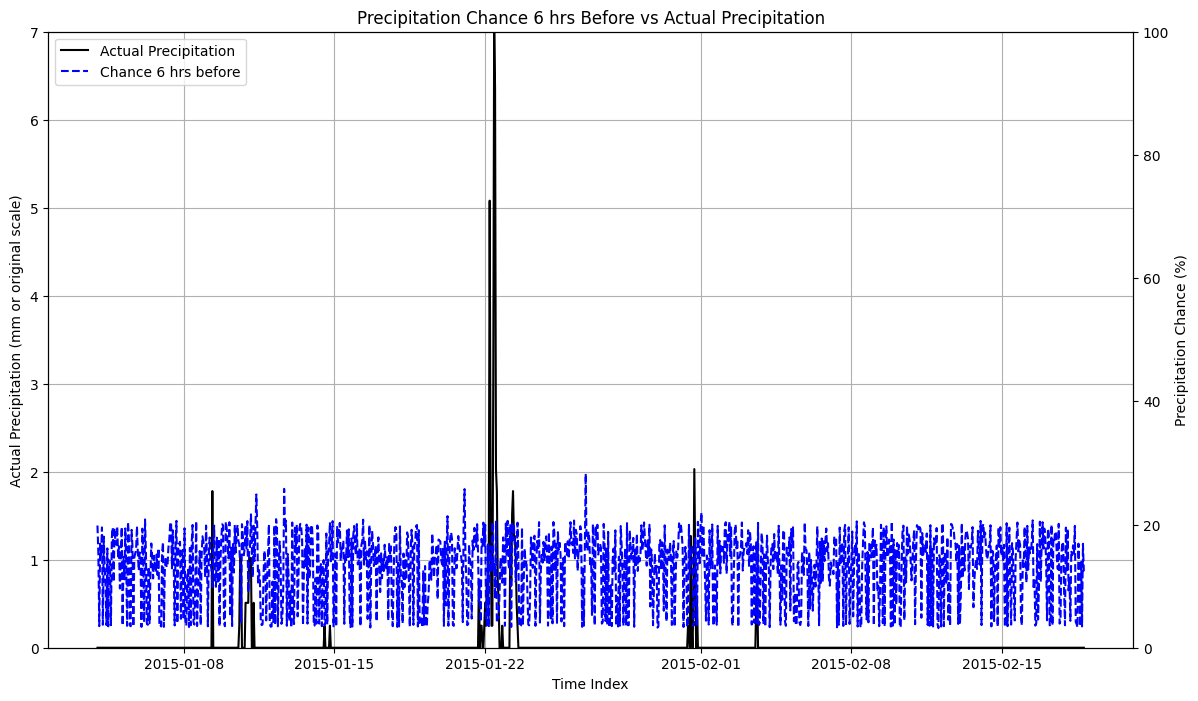

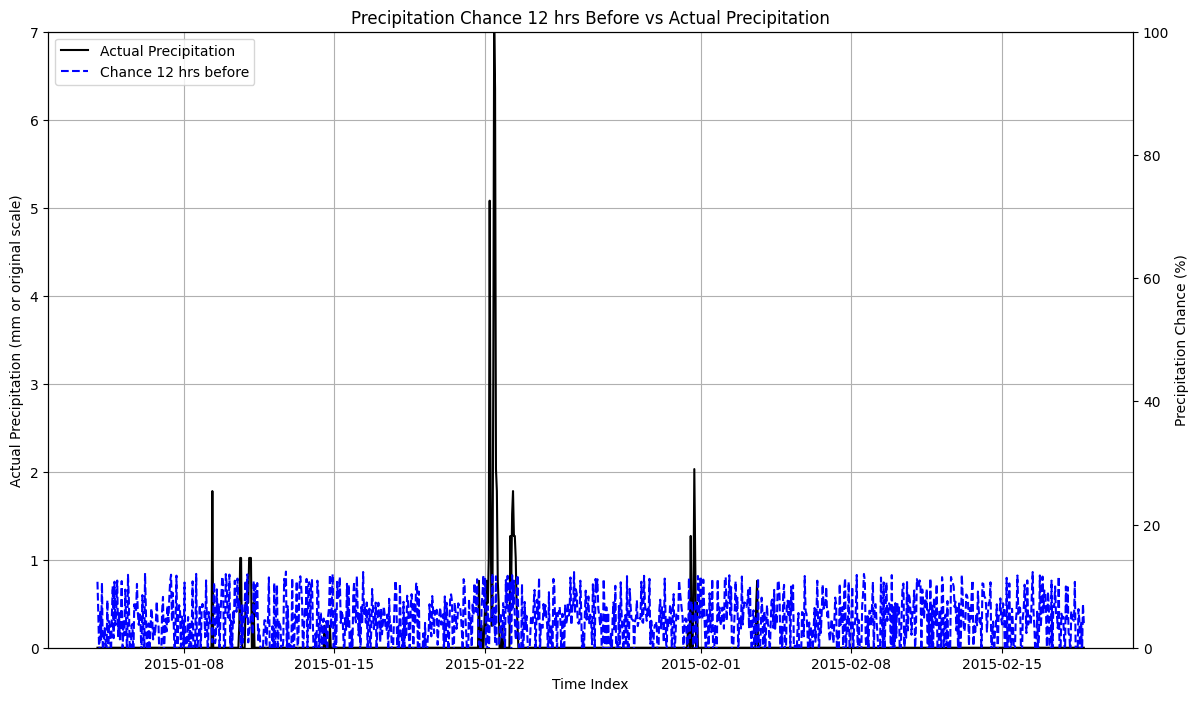

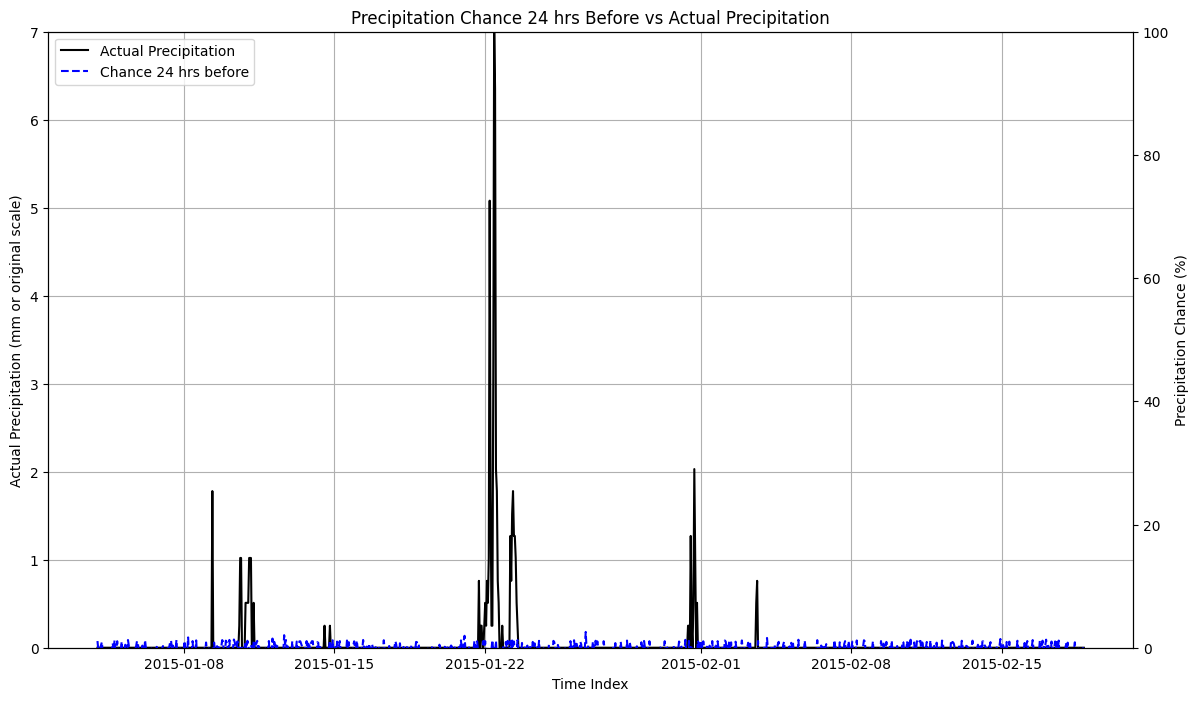

In [9]:
import matplotlib.pyplot as plt

def plot_precipitation_chances(df, target_intervals=[1, 3, 6, 12, 24], actual_column='Ppt', timeframe=(0, 100)):
    """
    Creates individual plots for each precipitation chance prediction interval, against actual precipitation values.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the precipitation chance columns and actual precipitation values.
        target_intervals (list): List of intervals (in hours) for which the precipitation chance is calculated.
        actual_column (str): Name of the actual precipitation column in the DataFrame.
        timeframe (tuple): Tuple (start, end) indicating the index range to plot for better visualization.
    """
    start, end = timeframe
    
    # Loop through each target interval and create a separate plot
    for interval in target_intervals:
        fig, ax1 = plt.subplots(figsize=(14, 8))
        
        # Plot actual precipitation values on the left y-axis
        ax1.plot(df.index[start:end], df[actual_column][start:end], label='Actual Precipitation', color='black', linewidth=1.5)
        ax1.set_xlabel('Time Index')
        ax1.set_ylabel('Actual Precipitation (mm or original scale)')
        ax1.set_ylim(0, 7)  # Keep the scale for actual precipitation
        ax1.grid(True)
        
        # Set up the secondary y-axis for precipitation chance as a percentage
        ax2 = ax1.twinx()
        
        # Plot the specific interval's precipitation chance, scaled to 0-100%
        ax2.plot(df.index[start:end], df[f'Ppt_pred_{interval}hr'][start:end] * 100, label=f'Chance {interval} hrs before', linestyle='--', color='blue')
        ax2.set_ylabel('Precipitation Chance (%)')
        ax2.set_ylim(0, 100)  # Scale to 0-100% for prediction chances
        
        # Add a combined legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        
        plt.title(f'Precipitation Chance {interval} hrs Before vs Actual Precipitation')
        plt.show()

# Call the function with the adjusted timeframe
plot_precipitation_chances(aligned_full_data, timeframe=(0, 1100))


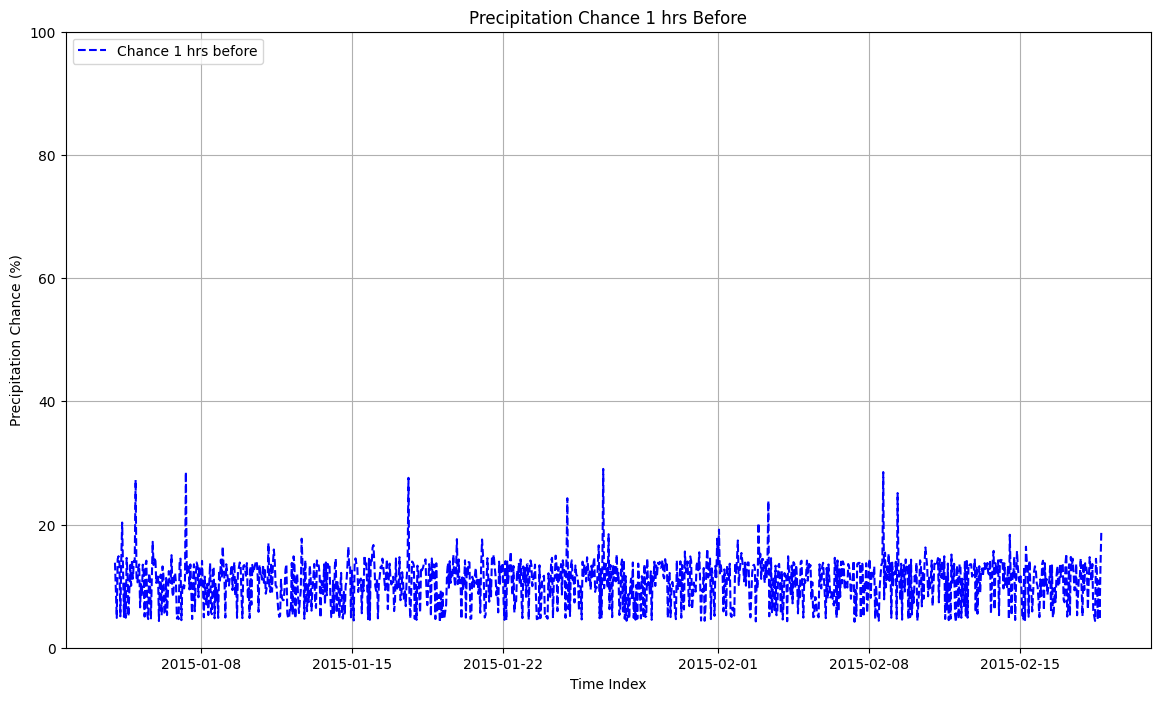

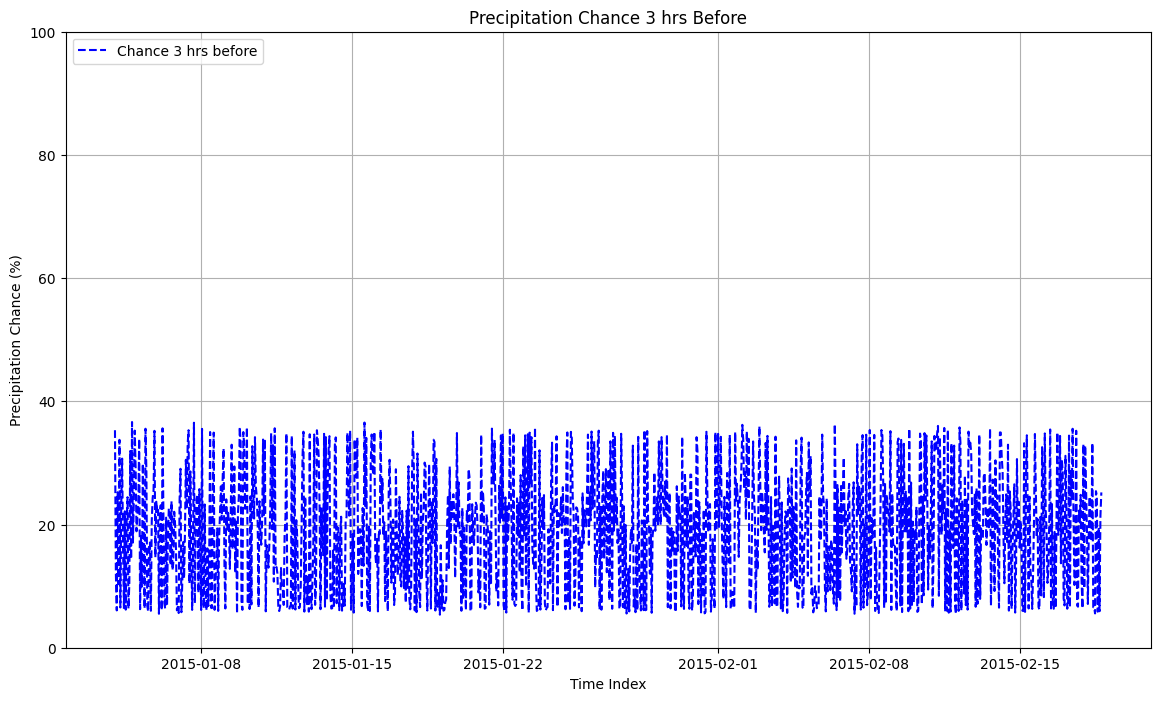

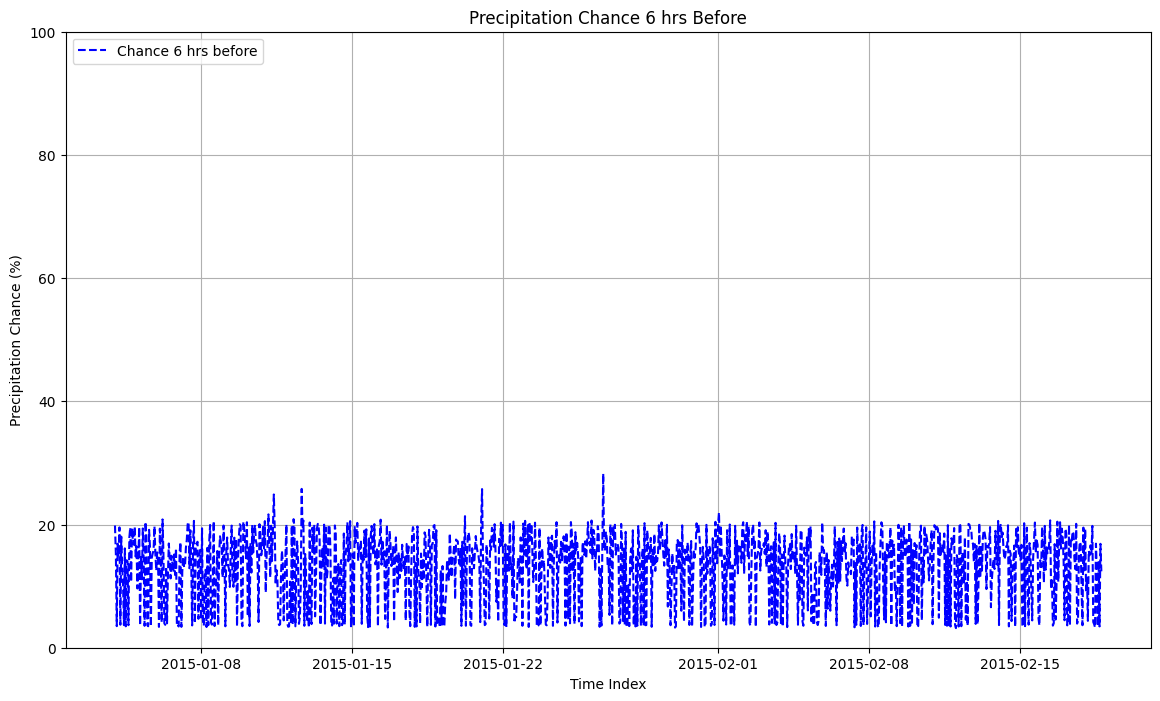

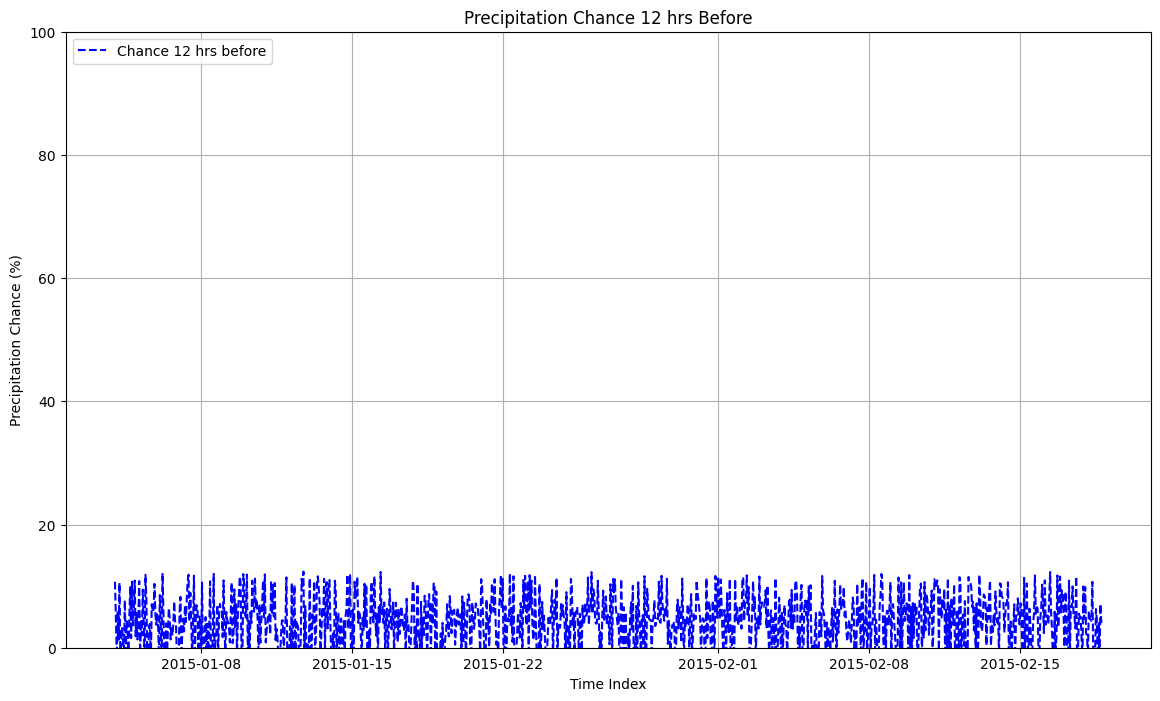

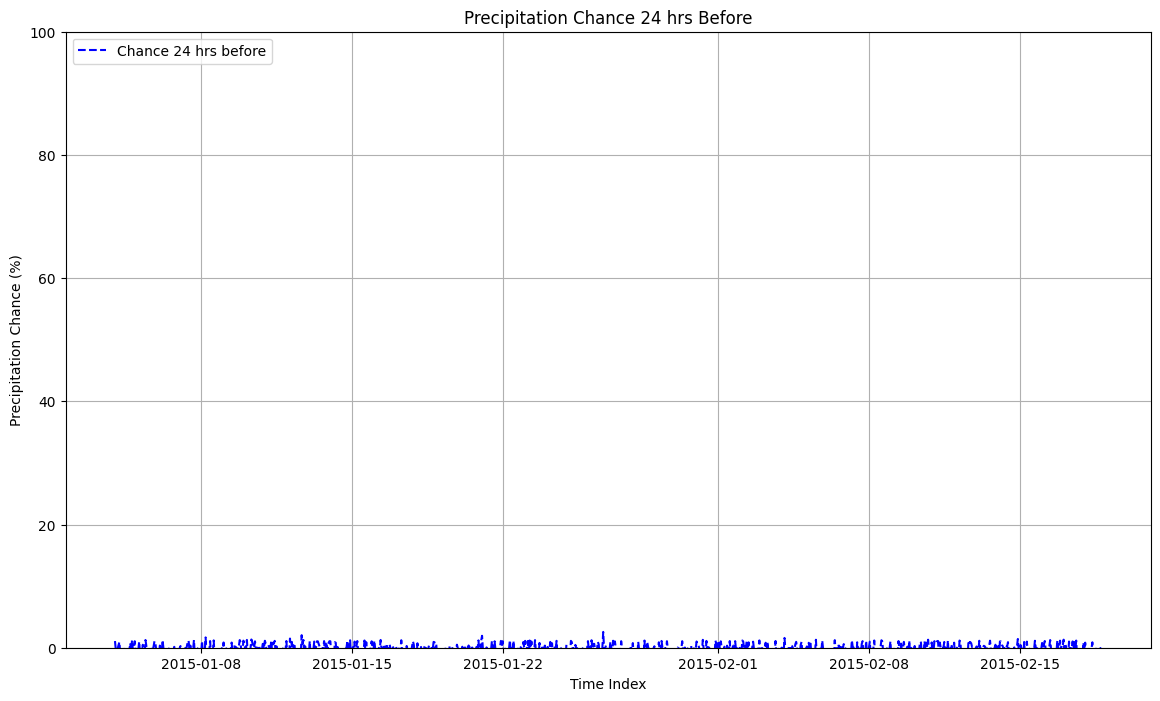

In [11]:

def plot_precipitation_chances_only(df, target_intervals=[1, 3, 6, 12, 24], timeframe=(0, 100)):
    """
    Creates individual plots for each precipitation chance prediction interval, without plotting actual precipitation values.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the precipitation chance columns.
        target_intervals (list): List of intervals (in hours) for which the precipitation chance is calculated.
        timeframe (tuple): Tuple (start, end) indicating the index range to plot for better visualization.
    """
    start, end = timeframe
    
    # Loop through each target interval and create a separate plot
    for interval in target_intervals:
        fig, ax2 = plt.subplots(figsize=(14, 8))
        
        # Plot the specific interval's precipitation chance, scaled to 0-100%
        ax2.plot(df.index[start:end], df[f'Ppt_pred_{interval}hr'][start:end] * 100, label=f'Chance {interval} hrs before', linestyle='--', color='blue')
        ax2.set_xlabel('Time Index')
        ax2.set_ylabel('Precipitation Chance (%)')
        ax2.set_ylim(0, 100)  # Scale to 0-100% for prediction chances
        ax2.grid(True)
        
        # Add legend
        ax2.legend(loc='upper left')
        
        plt.title(f'Precipitation Chance {interval} hrs Before')
        plt.show()

# Call the function with the adjusted timeframe
plot_precipitation_chances_only(aligned_full_data, timeframe=(0, 1100))


In [10]:
train_df.columns

Index(['Ppt', 'Ppt.1', 'Tair', 'RH', 'Srad', 'Wx', 'Wy', 'Day sin', 'Day cos',
       'Year sin', 'Year cos', 'Sum_Rain_1h', 'Sum_Rain_3h', 'Sum_Rain_6h',
       'Sum_Rain_12h', 'Sum_Rain_24h', 'Predicted_Rain_Next_Hour_1h',
       'Predicted_Rain_Next_Hour_3h', 'Predicted_Rain_Next_Hour_6h',
       'Predicted_Rain_Next_Hour_12h', 'Predicted_Rain_Next_Hour_24h',
       'Rain_Chance_Percentage_1d', 'Rain_Chance_Percentage_2d',
       'Rain_Chance_Percentage_3d', 'Rain_Chance_Percentage_4d',
       'Rain_Chance_Percentage_5d', 'Rain_Chance_Percentage_6d',
       'Rain_Chance_Percentage_7d', 'Rain_Chance_Percentage',
       'Predict_1days_Percentage', 'Predict_2days_Percentage',
       'Predict_3days_Percentage', 'Predict_4days_Percentage',
       'Predict_5days_Percentage', 'Predict_6days_Percentage',
       'Predict_7days_Percentage'],
      dtype='object')